In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv"
SLIDE_ID = "PT 35 B"
MAG = "40x"
CONCEPT_IDX = 27
STRIDE_PX = 224     # your patch stride (224 or 448 etc.)

df = pd.read_csv(CSV_PATH)

d = df[df["slide_id"] == SLIDE_ID].copy()
if MAG is not None:
    d = d[d["mag"] == MAG].copy()

if len(d) == 0:
    raise ValueError("No patches found.")

x = d["x"].to_numpy(np.float64)
y = d["y"].to_numpy(np.float64)

# origin at top-left of patch region
x0 = np.nanmin(x)
y0 = np.nanmin(y)

i = np.floor((x - x0) / STRIDE_PX).astype(np.int32)
j = np.floor((y - y0) / STRIDE_PX).astype(np.int32)

H = int(j.max()) + 1
W = int(i.max()) + 1

heat = np.zeros((H, W), dtype=np.float32)

vals = d[f"concept_{CONCEPT_IDX}"].to_numpy(np.float32)

# direct placement (no aggregation needed)
heat[j, i] = vals

# optional: normalize for visualization
v = heat[np.isfinite(heat)]
if v.size > 0:
    lo, hi = np.percentile(v, [2, 98])
else:
    lo, hi = None, None

plt.figure(figsize=(6,6))
# plt.imshow(heat, vmin=lo, vmax=hi)
plt.imshow(heat, vmin=lo, vmax=hi, interpolation="nearest", aspect="equal")

plt.colorbar()
plt.title(f"{SLIDE_ID} | concept_{CONCEPT_IDX}")
plt.tight_layout()
plt.show()


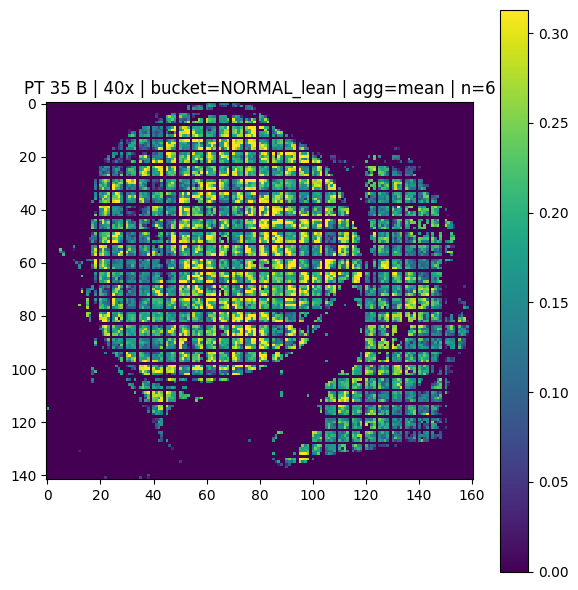

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv"
MAP_PATH = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_concept_map.csv"   # <-- your mapping file
SLIDE_ID = "PT 35 B"
MAG = "40x"

BUCKET = "NORMAL_lean"     # e.g., FA_lean, PT_lean, PT_malignant_like, mitosis, NORMAL_lean, controls
AGG = "mean"           # "mean" | "max" | "sum"
STRIDE_PX = 224

df = pd.read_csv(CSV_PATH)
cmap = pd.read_csv(MAP_PATH)

# --- find which concept indices belong to the bucket
idxs = cmap.loc[cmap["concept_group"] == BUCKET, "concept_idx"].astype(int).tolist()
if len(idxs) == 0:
    raise ValueError(f"No concepts found for bucket={BUCKET}")

concept_cols = [f"concept_{i}" for i in idxs]
missing = [c for c in concept_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns in concept CSV: {missing[:5]} (showing up to 5)")

# --- filter slide
d = df[df["slide_id"] == SLIDE_ID].copy()
if MAG is not None:
    d = d[d["mag"] == MAG].copy()
if len(d) == 0:
    raise ValueError("No patches found.")

x = d["x"].to_numpy(np.float64)
y = d["y"].to_numpy(np.float64)

# origin at top-left of patch region
x0 = np.nanmin(x)
y0 = np.nanmin(y)

i = np.floor((x - x0) / STRIDE_PX).astype(np.int32)
j = np.floor((y - y0) / STRIDE_PX).astype(np.int32)

H = int(j.max()) + 1
W = int(i.max()) + 1

# --- bucket score per patch
mat = d[concept_cols].to_numpy(np.float32)

if AGG == "mean":
    vals = mat.mean(axis=1)
elif AGG == "max":
    vals = mat.max(axis=1)
elif AGG == "sum":
    vals = mat.sum(axis=1)
else:
    raise ValueError("AGG must be one of: mean, max, sum")

# --- fill grid
heat = np.zeros((H, W), dtype=np.float32)
heat[j, i] = vals

# --- robust display range
v = heat[np.isfinite(heat)]
lo, hi = (np.percentile(v, [2, 98]) if v.size else (None, None))

plt.figure(figsize=(6, 6))
plt.imshow(heat, vmin=lo, vmax=hi, interpolation="nearest", aspect="equal")
plt.colorbar()
plt.title(f"{SLIDE_ID} | {MAG} | bucket={BUCKET} | agg={AGG} | n={len(idxs)}")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

CSV_PATH = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv"
MAP_PATH = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_concept_map.csv"

SLIDE_ID = "PT 52 B"
MAG = "40x"
STRIDE_PX = 224
AGG = "mean"   # mean or max

df = pd.read_csv(CSV_PATH)
cmap = pd.read_csv(MAP_PATH)

# --- filter slide
d = df[df["slide_id"] == SLIDE_ID].copy()
if MAG is not None:
    d = d[d["mag"] == MAG].copy()

# --- build bucket → concept mapping
bucket_to_idxs = (
    cmap.groupby("concept_group")["concept_idx"]
    .apply(list)
    .to_dict()
)

buckets = sorted(bucket_to_idxs.keys())
print("Buckets:", buckets)

# --- compute bucket scores per patch
bucket_scores = []

for b in buckets:
    idxs = bucket_to_idxs[b]
    cols = [f"concept_{i}" for i in idxs]
    mat = d[cols].to_numpy(np.float32)

    if AGG == "mean":
        score = mat.mean(axis=1)
    else:
        score = mat.max(axis=1)

    bucket_scores.append(score)

bucket_scores = np.stack(bucket_scores, axis=1)  # shape: (num_patches, num_buckets)

# --- winner bucket per patch
winner = np.argmax(bucket_scores, axis=1)

# --- grid mapping
x = d["x"].to_numpy()
y = d["y"].to_numpy()

x0, y0 = x.min(), y.min()
i = ((x - x0) // STRIDE_PX).astype(int)
j = ((y - y0) // STRIDE_PX).astype(int)

H = j.max() + 1
W = i.max() + 1

# heat = np.zeros((H, W), dtype=np.int32)
heat = np.full((H, W), -1, dtype=np.int32)

heat[j, i] = winner

# --- categorical colormap
cmap_vis = ListedColormap(plt.cm.tab10.colors[:len(buckets)])

for idx, b in enumerate(buckets):
    print(idx, b)

from matplotlib.colors import ListedColormap

colors = [
    "#1f77b4",  # FA_lean (blue)
    "#2ca02c",  # NORMAL_lean (green)
    "#ff7f0e",  # PT_benign_like (orange)
    "#d62728",  # PT_borderline_like (red)
    "#9467bd",  # PT_lean (purple)
    "#8c564b",  # PT_malignant_like (brown)
    "#7f7f7f",  # controls (gray)
    "#e377c2",  # mitosis (pink)
]

cmap_vis = ListedColormap(colors)

plt.figure(figsize=(6,6))
masked = np.ma.masked_where(heat == -1, heat)
plt.imshow(masked, interpolation="nearest", aspect="equal", cmap=cmap_vis)
# plt.imshow(heat, interpolation="nearest", aspect="equal", cmap=cmap_vis)

plt.colorbar(ticks=range(len(buckets)))
plt.clim(-0.5, len(buckets)-0.5)
plt.title(f"{SLIDE_ID} | winner bucket")
plt.tight_layout()
plt.show()


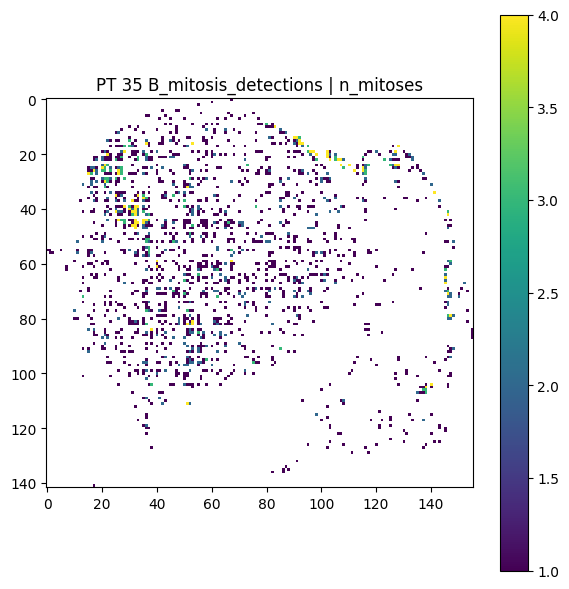

In [33]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DET_CSV   = r"C:\Users\Vivian\Documents\dsmil-wsi\roboflow\patch_feats.csv"
SLIDE_ID  = "PT 35 B_mitosis_detections"
VALUE_COL = "n_mitoses"   # or: n_highconf, conf_mean, conf_max, highconf_fraction, mitosis_present
STRIDE_PX = 224           # set to your patch stride (224 or 448)
FILL      = np.nan
ASPECT    = "equal"

# --- load
df = pd.read_csv(DET_CSV)
d = df[df["slide_id"] == SLIDE_ID].copy()
if len(d) == 0:
    raise ValueError("No rows for that slide.")

# --- parse x,y from patch_id like: patch_1002_x5600_y8064
m = d["patch_id"].str.extract(r"_x(?P<x>\d+)_y(?P<y>\d+)")
if m.isna().any().any():
    bad = d[m.isna().any(axis=1)].head(5)["patch_id"].tolist()
    raise ValueError(f"Failed to parse some patch_id values, e.g.: {bad}")

d["x"] = m["x"].astype(np.int64)
d["y"] = m["y"].astype(np.int64)

x = d["x"].to_numpy(np.float64)
y = d["y"].to_numpy(np.float64)

# origin at top-left of patch region
x0 = np.nanmin(x)
y0 = np.nanmin(y)

i = np.floor((x - x0) / STRIDE_PX).astype(np.int32)
j = np.floor((y - y0) / STRIDE_PX).astype(np.int32)

H = int(j.max()) + 1
W = int(i.max()) + 1

heat = np.full((H, W), FILL, dtype=np.float32)
vals = d[VALUE_COL].to_numpy(np.float32)

# direct placement (1 value per patch)
heat[j, i] = vals

# optional: robust display range
v = heat[np.isfinite(heat)]
lo, hi = (np.percentile(v, [2, 98]) if v.size else (None, None))

plt.figure(figsize=(6, 6))
plt.imshow(heat, interpolation="nearest", aspect=ASPECT, vmin=lo, vmax=hi)
plt.colorbar()
plt.title(f"{SLIDE_ID} | {VALUE_COL}")
plt.tight_layout()
plt.show()


In [39]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

concept_df = pd.read_csv(r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\slide_concept_scores\noCAP_patch_ptfile_notopk_conf_PATCH.csv")
robo_df    = pd.read_csv(r"C:\Users\Vivian\Documents\dsmil-wsi\roboflow\patch_feats.csv")

MITO_CONCEPT_IDX = 39
VALUE_COL = "n_mitoses"   # or n_highconf, mitosis_present, etc.

# --- clean slide ids FIRST (on full dfs)
concept_df["slide_id_clean"] = concept_df["slide_id"].astype(str).str.strip()
robo_df["slide_id_clean"]    = robo_df["slide_id"].astype(str).str.strip().str.replace("_mitosis_detections", "", regex=False)

# IMPORTANT: use the CLEAN id here (no suffix)
SLIDE_ID_CLEAN = "PT 35 B"

# --- filter slide AFTER cleaning
c = concept_df[concept_df["slide_id_clean"] == SLIDE_ID_CLEAN].copy()
r = robo_df[robo_df["slide_id_clean"] == SLIDE_ID_CLEAN].copy()

print("Concept rows:", len(c), "Robo rows:", len(r))

# --- parse x,y from roboflow patch_id inside the filtered r
m = r["patch_id"].astype(str).str.extract(r"_x(?P<x>\d+)_y(?P<y>\d+)")
if m.isna().any().any():
    bad = r.loc[m.isna().any(axis=1), "patch_id"].head(5).tolist()
    raise ValueError(f"Failed to parse some patch_id values, e.g.: {bad}")

r["x"] = m["x"].astype(np.int64)
r["y"] = m["y"].astype(np.int64)

# --- make sure concept x,y are ints too
c["x"] = c["x"].astype(np.int64)
c["y"] = c["y"].astype(np.int64)

# --- merge ON THE FILTERED dfs
merged = pd.merge(
    c,
    r,
    on=["slide_id_clean", "x", "y"],
    how="inner"
)

print("Matched patches:", len(merged))

# --- quantitative comparisons (only if matched)
if len(merged) > 0:
    concept_vals = merged[f"concept_{MITO_CONCEPT_IDX}"].to_numpy(np.float32)
    mito_vals    = merged[VALUE_COL].to_numpy(np.float32)

    # Spearman is usually best for sparse counts
    sp_r, sp_p = spearmanr(concept_vals, mito_vals)
    pe_r, pe_p = pearsonr(concept_vals, mito_vals) if np.std(mito_vals) > 0 and np.std(concept_vals) > 0 else (np.nan, np.nan)

    print(f"Spearman r={sp_r:.3f}, p={sp_p:.3g}")
    print(f"Pearson  r={pe_r:.3f}, p={pe_p:.3g}")


Concept rows: 8119 Robo rows: 1775
Matched patches: 1775
Spearman r=-0.163, p=4.89e-12
Pearson  r=-0.256, p=7.38e-28


In [35]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

c = merged[f"concept_{MITO_CONCEPT_IDX}"].to_numpy()
m = merged["n_mitoses"].to_numpy()

print("Spearman flipped:", spearmanr(-c, m))


Spearman flipped: SignificanceResult(statistic=0.16300259327796235, pvalue=4.886388934099277e-12)


In [40]:
from scipy.stats import mannwhitneyu

merged["mitosis_present"] = merged["mitosis_present"].fillna(0)

pos = merged[merged["mitosis_present"] == 1][f"concept_{MITO_CONCEPT_IDX}"]
neg = merged[merged["mitosis_present"] == 0][f"concept_{MITO_CONCEPT_IDX}"]

stat, p = mannwhitneyu(-pos, -neg)  # flip direction
print("Mann-Whitney p:", p)
print("Mean (mitosis patches):", (-pos).mean())
print("Mean (no mitosis):", (-neg).mean())


Mann-Whitney p: nan
Mean (mitosis patches): -0.23806930263329978
Mean (no mitosis): nan


C:\Users\Vivian\AppData\Local\Temp\ipykernel_31672\3955133643.py:8: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = mannwhitneyu(-pos, -neg)  # flip direction


scale ablation barplots for paper

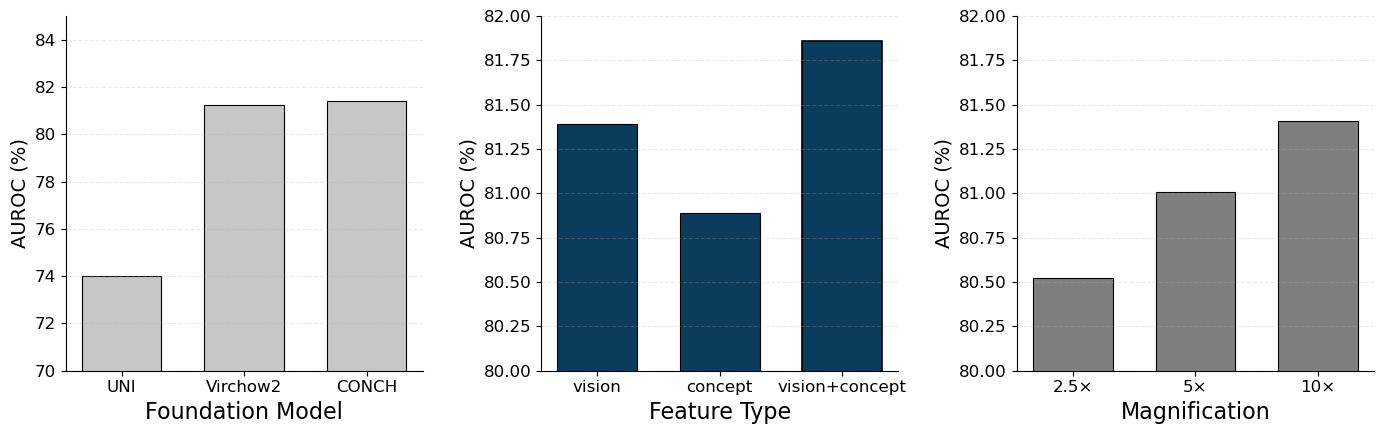

In [107]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Shared style / palette
# -------------------------
C_LIGHT = "#c7c7c7"   # light gray
C_MED   = "#7f7f7f"   # medium gray
C_BLUE  = "#1f4e79"   # dark blue
C_DARK  = "#0b3c5d"   # darkest blue (highlight / ours)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
plt.subplots_adjust(wspace=0.35)

# ============================================================
# Panel A: Foundation models (ABMIL vision)
# ============================================================
ax = axes[0]
backbones = ["UNI", "Virchow2", "CONCH"]
auc_means = np.array([74.01, 81.25, 81.39])
auc_stds  = np.array([9.22,  4.99,  5.57])

x = np.arange(len(backbones))
ax.bar(
    x, auc_means, width=0.65,
    # yerr=auc_stds, capsize=4,
    color=[C_LIGHT, C_LIGHT, C_LIGHT],
    edgecolor="black", linewidth=0.8
)
ax.set_xticks(x)
ax.set_xticklabels(backbones)
ax.set_ylabel("AUROC (%)")
# ax.set_title("Foundation Model (ABMIL, vision)")
ax.set_xlabel("Foundation Model", fontsize=16)
ax.set_ylim(70, 85)
ax.grid(axis="y", linestyle="--", alpha=0.25)

# ============================================================
# Panel B: Concept ablation (ABMIL) — reordered: concept, vision, vision+concept
# ============================================================
ax = axes[1]
models   = ["vision", "concept", "vision+concept"]
auc_mean = np.array([81.39, 80.89,  81.86])
auc_std  = np.array([5.57, 6.21,    5.01])

x = np.arange(len(models))
colors = [C_DARK, C_DARK, C_DARK]
edges  = ["black", "black", "black"]
lws    = [0.8, 0.8, 1.2]  # slightly thicker outline for "ours"

ax.bar(
    x, auc_mean, width=0.65,
    # yerr=auc_std, capsize=4,
    color=colors, edgecolor=edges, linewidth=lws
)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("AUROC (%)")
# ax.set_title("Feature Type (ABMIL)")
ax.set_xlabel("Feature Type", fontsize=16)
ax.set_ylim(80, 82)
ax.grid(axis="y", linestyle="--", alpha=0.25)

# ============================================================
# Panel C: Magnification ablation (ABMIL, vision+concept) — same color everywhere
# ============================================================
ax = axes[2]
scales = ["2.5×", "5×", "10×"]
auc_means = np.array([80.52, 81.01, 81.41])
auc_stds  = np.array([8.37,  5.18,  5.68])

x = np.arange(len(scales))
ax.bar(
    x, auc_means, width=0.65,
    # yerr=auc_stds, capsize=4,
    color=C_MED, edgecolor="black", linewidth=0.8
)
ax.set_xticks(x)
ax.set_xticklabels(scales)
ax.set_ylabel("AUROC (%)")
# ax.set_title("Magnification (ABMIL, vision+concept)")
ax.set_xlabel("Magnification", fontsize=16)
ax.set_ylim(80, 82)
ax.grid(axis="y", linestyle="--", alpha=0.25)

# Final polish
for ax in axes:
    ax.tick_params(axis="both", labelsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import torch
# C:\Users\Vivian\Documents\CONCH\run2_conch15_img_feats\pt\FA 56B.pt
# C:\Users\Vivian\Documents\CONCH\conch15_img_feats\pt\FA 56B.pt
# C:\Users\Vivian\Documents\CONCH\conch_img_feats\10x_feats\conchextracted_mag10x_patch224_fp\feats_pt\FA 56B.pt
d = torch.load(r"C:\Users\Vivian\Documents\CONCH\conch_img_feats\10x_feats\conchextracted_mag10x_patch224_fp\feats_pt\FA 56B.pt")
feats = d["features"]

# check norm
norms = feats.norm(dim=1)
print(norms.mean(), norms.std())

# print shape 
print(feats.shape)

# conch v1.5
# tensor(27.8001) tensor(0.0170)
# torch.Size([3360, 768])

# conch v1
# tensor(31.9991) tensor(1.3750e-05)
# torch.Size([3360, 1024])

tensor(1.) tensor(4.1585e-08)
torch.Size([3360, 512])


C:\Users\Vivian\AppData\Local\Temp\ipykernel_34436\3122282907.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(r"C:\Users\Vivian\Documents\CONCH\conch_img_

In [8]:
d_virchow = torch.load(r"C:\Users\Vivian\Documents\CONCH\virchow2_img_feats\10x_feats\40x\pt\FA 47 B1.pt")
feats_virchow = d_virchow["features"]
norms_virchow = feats_virchow.norm(dim=1)
print(norms_virchow.mean(), norms_virchow.std())

tensor(44.0339) tensor(3.4675)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_34436\483134034.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d_virchow = torch.load(r"C:\Users\Vivian\Documents\CONCH\vir

In [6]:
d_uni = torch.load(r'C:\Users\Vivian\Documents\CLAM\CLAM\FEATURES_DIR_5x\FEATURES_DIR_10x\uniextracted_mag10x_patch224_fp\feats_pt\FA 47 B1.pt')

# tensor object print norm
norms_uni = d_uni.norm(dim=1)
print(norms_uni.mean(), norms_uni.std())

tensor(38.7646) tensor(0.5594)


C:\Users\Vivian\AppData\Local\Temp\ipykernel_34436\211851652.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d_uni = torch.load(r'C:\Users\Vivian\Documents\CLAM\CLAM\FEA